<a href="https://colab.research.google.com/github/Piyush-Sharma-1/Diffusion_from_Scratch/blob/main/Week%206/Navigating_latent_space_CelebA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SoC Diffusion — Week 6: Navigating Latent Space (Milestone 2)

This notebook is inference-only — no training. It:
1. Loads  Week 5 `Mnist_Vae'
2. Generates a face-morphing GIF (Part 1)
3. Discovers attribute directions + attribute grid (Part 2)
4. Does cross-attribute latent arithmetic (Part 3)
5. Answers the reflection questions (Part 4)
6. Random-direction latent walk



## Step 0: Setup & Load Your Model

In [90]:
!pip install imageio -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import imageio
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [91]:
# ===== MOUNT DRIVE =============
from google.colab import drive
drive.mount('/content/drive')
MODEL_PATH = "/content/drive/MyDrive/week5_submission/model.pt"

assert os.path.exists(MODEL_PATH), f"Could not find {MODEL_PATH} - fix the path above!"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
# Recreate the model architecture (MUST match Week 5 exactly, including hidden_dims/latent_dim)
class FaceVAE(nn.Module):
    def __init__(self, latent_dim=128, hidden_dims=None, kernel_size=3):
        super().__init__()
        self.latent_dim = latent_dim
        if hidden_dims is None:
            hidden_dims = [64, 128, 256, 512]  # must match training config!

        encoder_layers = []
        in_ch = 3
        for out_ch in hidden_dims:
            encoder_layers.extend([
                nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
            ])
            in_ch = out_ch
        encoder_layers.append(nn.Flatten())
        self.encoder = nn.Sequential(*encoder_layers)

        n_layers = len(hidden_dims)
        spatial_size = 64 // (2 ** n_layers)
        self.flattened_size = hidden_dims[-1] * (spatial_size ** 2)
        self.spatial_size = spatial_size
        self.last_channel = hidden_dims[-1]

        self.fc_mu = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, self.flattened_size)
        decoder_layers = []
        rev_dims = list(reversed(hidden_dims))
        for i in range(len(rev_dims) - 1):
            decoder_layers.extend([
                nn.ConvTranspose2d(rev_dims[i], rev_dims[i+1], kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(rev_dims[i+1]),
                nn.ReLU(),
            ])
        decoder_layers.extend([
            nn.ConvTranspose2d(rev_dims[-1], 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        ])
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, self.last_channel, self.spatial_size, self.spatial_size)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


model = FaceVAE(latent_dim=128).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Model loaded successfully!")


Model loaded successfully!


In [93]:
!pip install kaggle -q

import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Kaggle username: ")
os.environ['KAGGLE_KEY'] = getpass("Kaggle API key (hidden): ")

!kaggle datasets download -d jessicali9530/celeba-dataset -p /content/celeba_data --unzip

Kaggle username: phantomygyj
Kaggle API key (hidden): ··········
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:16<00:00, 86.9MB/s]



In [94]:
# --- Build the dataset ---
import pandas as pd
from PIL import Image as PILImage

image_size = 64
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
])

CELEBA_ROOT = "/content/celeba_data"
IMG_DIR = os.path.join(CELEBA_ROOT, "img_align_celeba", "img_align_celeba")

attr_df = pd.read_csv(os.path.join(CELEBA_ROOT, "list_attr_celeba.csv"))
ATTR_NAMES = list(attr_df.columns[1:])  # 40 attribute names, in official CelebA order
# Kaggle mirrors the original -1/1 encoding -> convert to 0/1 to match the rest of this notebook
attr_df[ATTR_NAMES] = (attr_df[ATTR_NAMES] + 1) // 2

partition_df = pd.read_csv(os.path.join(CELEBA_ROOT, "list_eval_partition.csv"))
train_ids = set(partition_df.loc[partition_df['partition'] == 0, 'image_id'])
train_df = attr_df[attr_df['image_id'].isin(train_ids)].reset_index(drop=True)


class CelebADataset(torch.utils.data.Dataset):
    """Drop-in replacement for torchvision.datasets.CelebA, backed by the Kaggle files."""
    def __init__(self, df, img_dir, transform, with_attrs=True):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.with_attrs = with_attrs

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = PILImage.open(os.path.join(self.img_dir, row['image_id'])).convert('RGB')
        img = self.transform(img)
        if self.with_attrs:
            attrs = torch.tensor(row[ATTR_NAMES].values.astype('int64'))
            return img, attrs
        return img, 0


dataset_with_attrs = CelebADataset(train_df, IMG_DIR, transform, with_attrs=True)
dataset = CelebADataset(train_df, IMG_DIR, transform, with_attrs=False)

loader = DataLoader(dataset, batch_size=64, shuffle=True)
print("Dataset ready:", len(dataset), "images")

Dataset ready: 162770 images


## Part 1 — Face Morphing GIF

GIF saved to /content/outputs/face_morph.gif


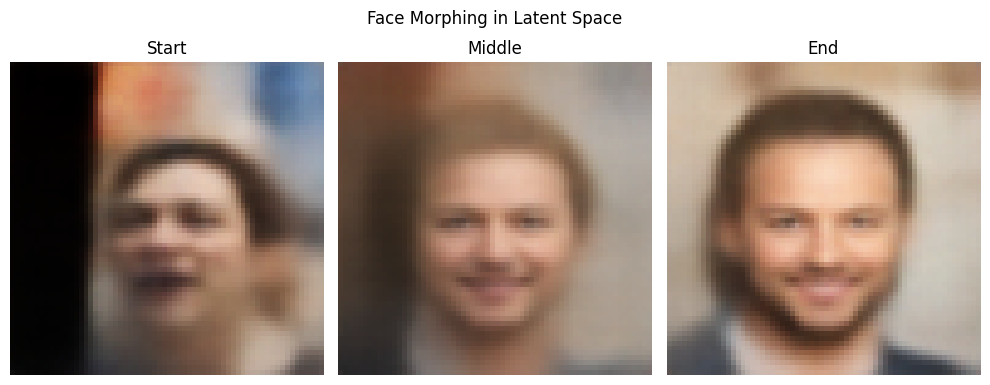

In [95]:
@torch.no_grad()
def face_morph(model, img1, img2, steps=100):  # more steps = smoother GIF
    """Linear interpolation between two encoded faces."""
    mu1, _ = model.encode(img1.to(device))
    mu2, _ = model.encode(img2.to(device))

    frames = []
    for alpha in np.linspace(0, 1, steps):
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        recon = model.decode(z_interp)
        frame = recon[0].cpu().permute(1, 2, 0).numpy()
        frame = np.clip(frame, 0, 1)
        frames.append((frame * 255).astype(np.uint8))
    return frames


# Grab two different faces
x, _ = next(iter(loader))
img1 = x[0:1]
img2 = x[1:2]

frames = face_morph(model, img1, img2, steps=30)

os.makedirs("/content/outputs", exist_ok=True)
gif_path = "/content/outputs/face_morph.gif"
imageio.mimsave(gif_path, frames, duration=0.1, loop=0)
print("GIF saved to", gif_path)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(frames[0]);  axes[0].set_title("Start");  axes[0].axis('off')
axes[1].imshow(frames[15]); axes[1].set_title("Middle"); axes[1].axis('off')
axes[2].imshow(frames[-1]); axes[2].set_title("End");    axes[2].axis('off')
plt.suptitle("Face Morphing in Latent Space")
plt.tight_layout()
plt.savefig("/content/outputs/morph_start_mid_end.png", dpi=150)
plt.show()


## Part 2 — Attribute Discovery
- [ ]  attribute vectors
- [ ] Attribute grid at strengths [-2, -1, 0, 1, 2]
- [ ] Each attribute shows a visible, consistent effect


In [96]:
ATTR_NAMES = [
    '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes',
    'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair',
    'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin',
    'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',
    'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
    'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline',
    'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair',
    'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick',
    'Wearing_Necklace', 'Wearing_Necktie', 'Young'
]

@torch.no_grad()
def encode_batch(model, loader, max_batch=1000):
    """Encode images from loader until we have >= max_batch mu vectors."""
    all_mu, all_attrs = [], []
    for x, attrs in loader:
        mu, _ = model.encode(x.to(device))
        all_mu.append(mu.cpu())
        all_attrs.append(attrs)
        if sum(m.shape[0] for m in all_mu) >= max_batch:
            break
    return torch.cat(all_mu), torch.cat(all_attrs)


def get_attribute_vector(model, loader_with_attrs, attr_name, n_samples=2000):
    attr_idx = ATTR_NAMES.index(attr_name)
    mu_vectors, attr_labels = encode_batch(model, loader_with_attrs, max_batch=n_samples)

    has_attr = attr_labels[:, attr_idx] == 1
    no_attr  = attr_labels[:, attr_idx] == 0  # torchvision CelebA attrs are 0/1, not -1/1

    mu_with = mu_vectors[has_attr]
    mu_without = mu_vectors[no_attr]

    if len(mu_with) < 10 or len(mu_without) < 10:
        print(f"Warning: not enough samples for '{attr_name}'. Got {len(mu_with)}/{len(mu_without)}")
        return None

    return mu_with.mean(dim=0) - mu_without.mean(dim=0)


@torch.no_grad()
def apply_attribute(model, img, attr_vector, strength=1.0):
    mu, _ = model.encode(img.to(device))
    mu_modified = mu + strength * attr_vector.to(device)
    return model.decode(mu_modified).cpu()


attr_loader = DataLoader(dataset_with_attrs, batch_size=128, shuffle=True)


In [97]:

attributes_to_find = ['Smiling', 'Male', 'Eyeglasses','Bangs','Pale_Skin']  # add more, e.g. 'Young', 'Bangs', 'Heavy_Makeup'

attr_vectors = {}
print("Computing attribute vectors...")
for attr in tqdm(attributes_to_find):
    vec = get_attribute_vector(model, attr_loader, attr, n_samples=2000)
    if vec is not None:
        attr_vectors[attr] = vec
        print(f"  {attr}: vector norm = {vec.norm():.3f}")

print(f"\nFound {len(attr_vectors)}/{len(attributes_to_find)} attribute directions")


Computing attribute vectors...


 20%|██        | 1/5 [00:04<00:19,  4.92s/it]

  Smiling: vector norm = 1.558


 40%|████      | 2/5 [00:12<00:20,  6.68s/it]

  Male: vector norm = 1.573


...

  Eyeglasses: vector norm = 1.891


 80%|████████  | 4/5 [00:19<00:04,  4.54s/it]

  Bangs: vector norm = 1.735


100%|██████████| 5/5 [00:23<00:00,  4.66s/it]

  Pale_Skin: vector norm = 1.988

Found 5/5 attribute directions


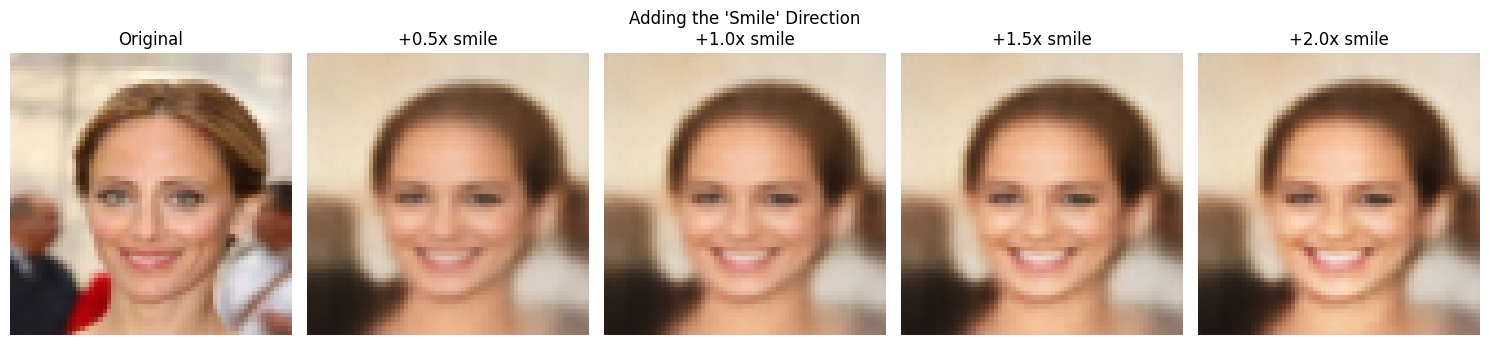

In [98]:
# Single attribute demo (Smiling)
x, _ = next(iter(loader))
test_face = x[0:1]
smile_vector = attr_vectors['Smiling']

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
axes[0].imshow(test_face[0].permute(1, 2, 0)); axes[0].set_title("Original"); axes[0].axis('off')
for i, strength in enumerate([0.5, 1.0, 1.5, 2.0]):
    modified = apply_attribute(model, test_face, smile_vector, strength=strength)
    axes[i+1].imshow(modified[0].permute(1, 2, 0))
    axes[i+1].set_title(f"+{strength}x smile")
    axes[i+1].axis('off')
plt.suptitle("Adding the 'Smile' Direction")
plt.tight_layout()
plt.savefig("/content/outputs/smile_direction.png", dpi=100)
plt.show()


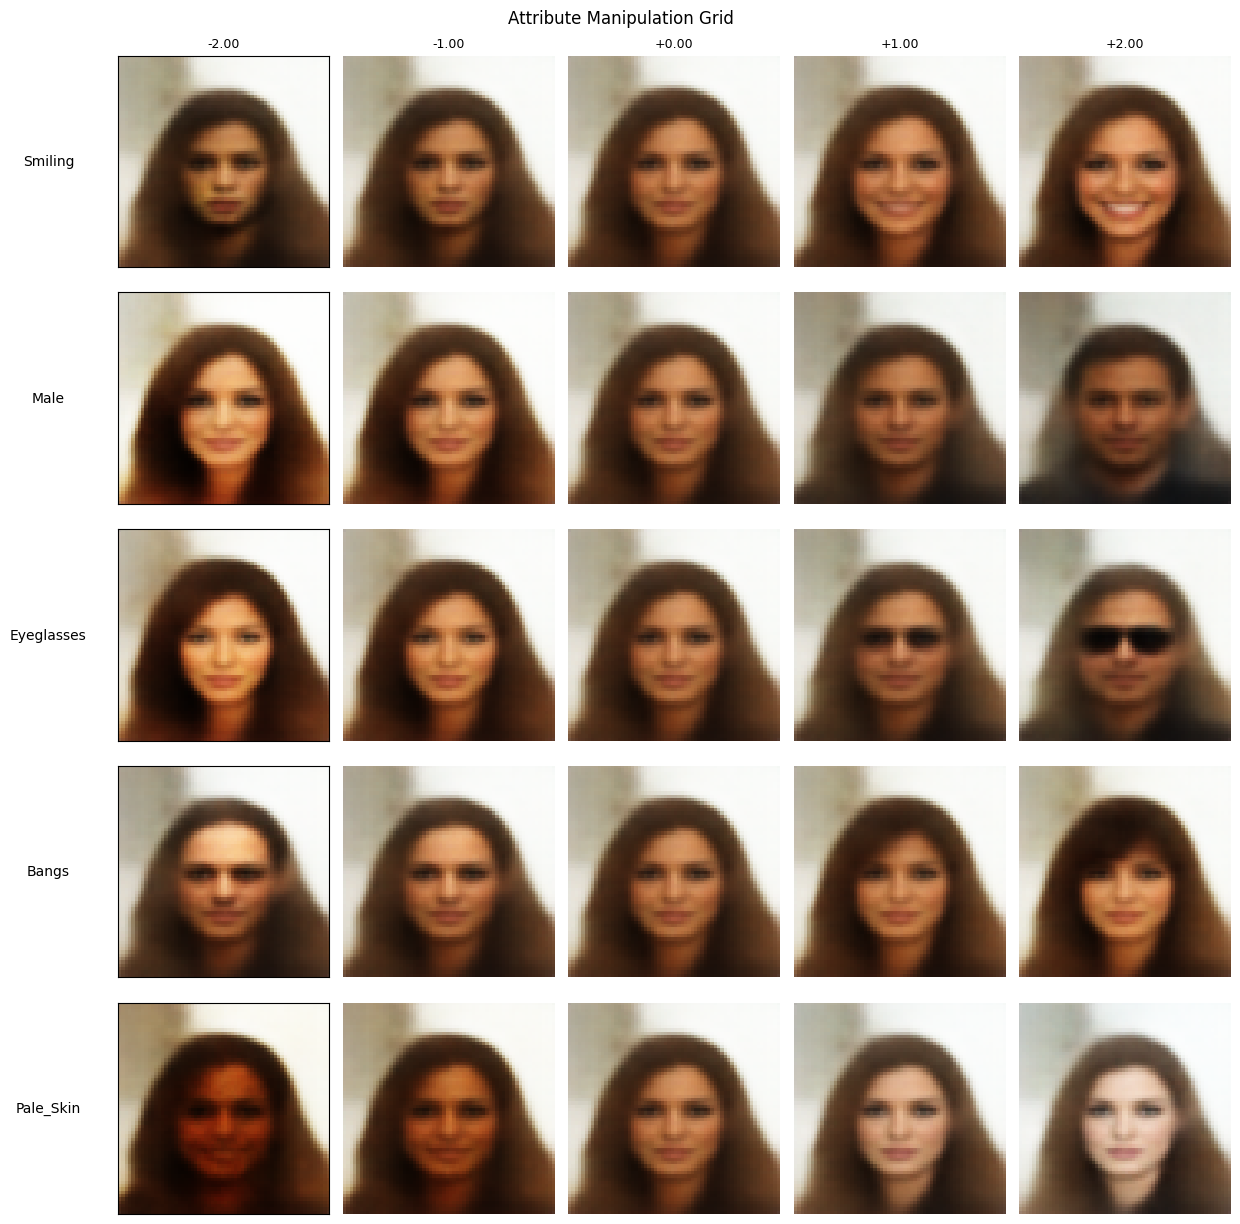

In [104]:
@torch.no_grad()
def attribute_grid(model, loader, attr_vectors, face_idx=0, strengths=(-2, -1, 0, 1, 2)):
    """Grid: rows = attributes, cols = strengths, for one fixed base face."""
    x, _ = next(iter(loader))
    base_face = x[face_idx:face_idx+1]

    n_attrs = len(attr_vectors)
    n_strengths = len(strengths)

    fig, axes = plt.subplots(n_attrs, n_strengths, figsize=(n_strengths * 2.5, n_attrs * 2.5))
    if n_attrs == 1:
        axes = axes[None, :]  # keep 2D indexing consistent

    for row, (attr_name, vec) in enumerate(attr_vectors.items()):
        for col, strength in enumerate(strengths):
            modified = apply_attribute(model, base_face, vec, strength=strength)
            axes[row, col].imshow(modified[0].permute(1, 2, 0))
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(attr_name, fontsize=10, rotation=0, labelpad=50, va='center')
                axes[row, col].axis('on')
                axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
            if row == 0:
                axes[row, col].set_title(f"{strength:+.2f}", fontsize=9)

    plt.suptitle("Attribute Manipulation Grid")
    plt.tight_layout()
    plt.savefig("/content/outputs/attribute_grid.png", dpi=150)
    plt.show()

attribute_grid(model, loader, attr_vectors)


## Part 3 — Latent Arithmetic
- [ ] Cross-attribute arithmetic (e.g. smile + younger)
- [ ] Original / single attribute / combined attributes comparison figure


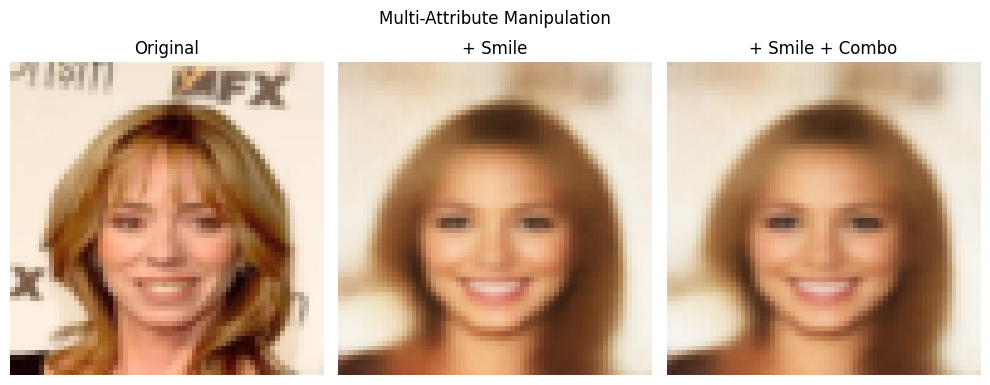

In [100]:
# Cross-attribute arithmetic: e.g. make a face smile AND look more/less "Male"
test_face = x[5:6] if x.shape[0] > 5 else x[0:1]
mu, _ = model.encode(test_face.to(device))

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(test_face[0].permute(1, 2, 0)); axes[0].set_title("Original"); axes[0].axis('off')

mu_smiling = mu + attr_vectors['Smiling'].to(device)
recon_smile = model.decode(mu_smiling)
axes[1].imshow(recon_smile[0].detach().cpu().permute(1, 2, 0)); axes[1].set_title("+ Smile"); axes[1].axis('off')

# combine two attribute vectors (edit weights / attributes to explore)
combo_vec = attr_vectors['Smiling'] + 0.5 * attr_vectors.get('Eyeglasses', attr_vectors['Male'])
mu_combo = mu + combo_vec.to(device)
recon_combo = model.decode(mu_combo)
axes[2].imshow(recon_combo[0].detach().cpu().permute(1, 2, 0)); axes[2].set_title("+ Smile + Combo"); axes[2].axis('off')

plt.suptitle("Multi-Attribute Manipulation")
plt.tight_layout()
plt.savefig("/content/outputs/cross_attribute_arithmetic.png", dpi=150)
plt.show()


## Bonus — Random Walk Visualization
- [ ] 3 random walks in different directions from the same face
- [ ] Description of what changes in each walk


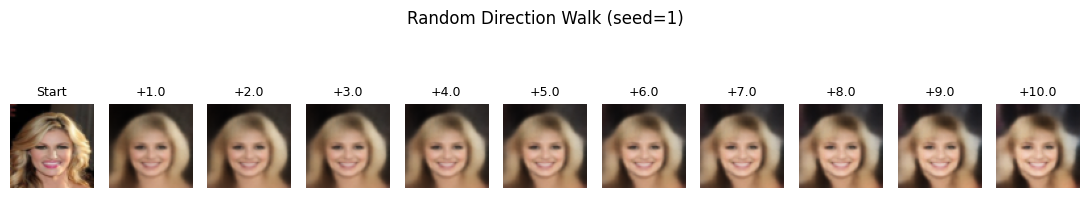

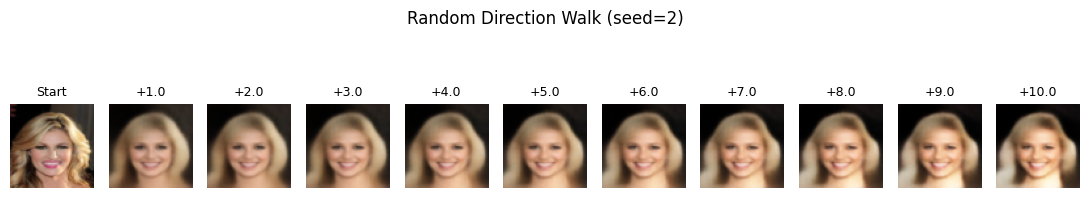

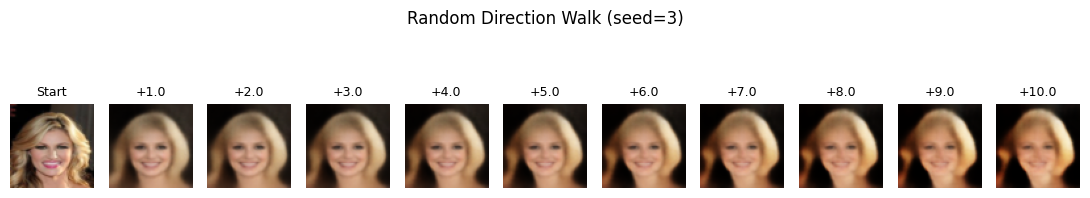

In [101]:
@torch.no_grad()
def random_walk(model, base_face, n_steps=20, step_size=1.0, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    mu, _ = model.encode(base_face.to(device))
    random_direction = torch.randn(1, model.latent_dim).to(device)
    random_direction = random_direction / random_direction.norm()

    fig, axes = plt.subplots(1, n_steps + 1, figsize=(n_steps + 1, 2.5))
    axes[0].imshow(base_face[0].permute(1, 2, 0)); axes[0].set_title("Start", fontsize=9); axes[0].axis('off')

    for i in range(1, n_steps + 1):
        z = mu + step_size * i * random_direction
        recon = model.decode(z)
        axes[i].imshow(recon[0].cpu().permute(1, 2, 0))
        axes[i].set_title(f"+{i*step_size:.1f}", fontsize=9)
        axes[i].axis('off')

    plt.suptitle(f"Random Direction Walk (seed={seed})")
    plt.tight_layout()
    plt.savefig(f"/content/outputs/random_walk_seed{seed}.png", dpi=150)
    plt.show()

base_face = x[3:4] if x.shape[0] > 3 else x[0:1]
for seed in [1, 2, 3]:
    random_walk(model, base_face, n_steps=10, step_size=1.0, seed=seed)


**Observations:**

_All three random walks converged pretty fast — by around +2 to +3, the face turned into a generic smiling face, then barely changed for the rest of the way to +10. None of the directions did anything specific or recognizable, they just drifted toward an "average" face. This shows random directions aren't really meaningful on their own — unlike the attribute vectors I computed on purpose, which actually target something real._


## Part 4 — Reflection

**1. Which attribute does your model represent best? Which is worst? Why do you think that is?**

_Smiling came out the best — from -2.0 to +2.0 you can clearly see the mouth close into a neutral look on one end and open into a full smile with visible teeth on the other, smooth the whole way through. Eyeglasses was the worst — nothing changes until +1.0, and even then it barely looks like glasses; by +2.0 it suddenly jumps to sunglasses instead of a gradual change. It's less like a smooth attribute and more like a switch that flips late. I think this is because a smile is a big, obvious change with tons of clear examples in the dataset, while glasses are small and thin, so the model never really learned a clean, gradual direction for them._

**2. If you were building a face-editing app, what would you need to improve about your VAE?**

_Mainly resolution — everything is blurry at 64x64, so edits never look fully convincing. I'd also train with a higher β to force the model to separate attributes more cleanly, since right now some directions probably drag other features along with them. And I'd compute the attribute vectors from way more samples than 2000 to make the directions less noisy._


## Saving  deliverables (GIF + screenshots) with a Drive link



In [102]:
import shutil

DRIVE_SUBMIT_DIR = "/content/drive/MyDrive/soc_diffusion/week6_submission"
os.makedirs(DRIVE_SUBMIT_DIR, exist_ok=True)

for fname in os.listdir("/content/outputs"):
    shutil.copy(os.path.join("/content/outputs", fname), os.path.join(DRIVE_SUBMIT_DIR, fname))

print("Copied these files to", DRIVE_SUBMIT_DIR)
print(os.listdir(DRIVE_SUBMIT_DIR))
print()



Copied these files to /content/drive/MyDrive/soc_diffusion/week6_submission
['cross_attribute_arithmetic.png', 'random_walk_seed3.png', 'face_morph.gif', 'morph_start_mid_end.png', 'random_walk_seed1.png', 'smile_direction.png', 'random_walk_seed2.png', 'attribute_grid.png']

